# BÀI 1: KHẢO SÁT VÀ TIỀN XỬ LÝ DỮ LIỆU
* **Môn học:** Khai thác dữ liệu

* **Thực hiện:** Nguyễn Trường Duy, Lý Gia Hào

---
## 1. Bộ dữ liệu D1: Default of Credit Card Clients
Sử dụng dữ liệu lịch sử tín dụng (10.000 bản ghi, 25 thuộc tính) để chuẩn bị cho bài toán Phân lớp (dự đoán nợ xấu) và Gom cụm (phân khúc khách hàng).

=== Ô CODE 1: XỬ LÝ BỘ D1 MỚI (UCI CREDIT CARD) ===
Kích thước D1 mới: 10000 bản ghi, 24 thuộc tính.


,Kiểu dữ liệu,Số lượng rỗng
LIMIT_BAL,float64,0
SEX,int64,0
EDUCATION,int64,0
MARRIAGE,int64,0
AGE,int64,0


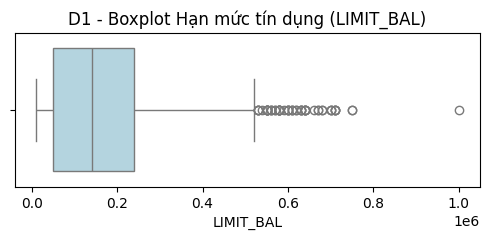

-> Tiền xử lý D1 mới hoàn tất!



In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from IPython.display import display

print("=== Ô CODE 1: XỬ LÝ BỘ D1 MỚI (UCI CREDIT CARD) ===")
try:
    # 1. Tải dữ liệu, lấy 10.000 dòng đầu để đồng bộ quy mô dự án
    df1 = pd.read_csv('UCI_Credit_Card.csv', nrows=10000)

    # 2. Xóa cột ID vì không có giá trị trong khai phá dữ liệu
    df1 = df1.drop(columns=['ID'], errors='ignore')
    print(f"Kích thước D1 mới: {df1.shape[0]} bản ghi, {df1.shape[1]} thuộc tính.")

    # 3. In Từ điển dữ liệu cơ bản
    dict_d1 = pd.DataFrame({'Kiểu dữ liệu': df1.dtypes, 'Số lượng rỗng': df1.isnull().sum()})
    display(dict_d1.head())

    # 4. Vẽ Boxplot kiểm tra ngoại lai của Hạn mức tín dụng (LIMIT_BAL)
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df1['LIMIT_BAL'], color='lightblue')
    plt.title('D1 - Boxplot Hạn mức tín dụng (LIMIT_BAL)')
    plt.show()

    # 5. Chuẩn hóa dữ liệu (Standardization) cho một số cột có giá trị số lớn
    cols_to_scale = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
    df1[cols_to_scale] = StandardScaler().fit_transform(df1[cols_to_scale])

    print("-> Tiền xử lý D1 mới hoàn tất!\n")

except FileNotFoundError:
    print("LỖI: Chưa tìm thấy file 'UCI_Credit_Card.csv'. Vui lòng kiểm tra lại thư mục.")
except Exception as e:
    print("LỖI D1:", e)

## 2. Bộ dữ liệu D2: Hotel Booking Demand
Khảo sát và xử lý 10.000 bản ghi dữ liệu đặt phòng khách sạn, sẵn sàng cho bài toán Phân lớp và Luật kết hợp.

=== Ô CODE 2: XỬ LÝ BỘ D2 (HOTEL BOOKING) ===
Kích thước D2: 10000 bản ghi, 30 thuộc tính.


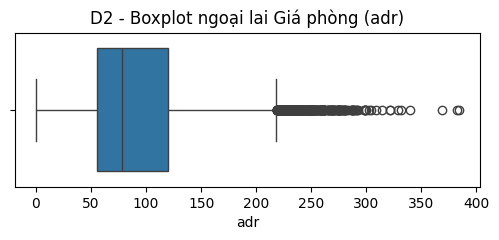

-> Tiền xử lý D2 hoàn tất!



In [21]:
print("=== Ô CODE 2: XỬ LÝ BỘ D2 (HOTEL BOOKING) ===")
try:
    df2 = pd.read_csv('hotel_bookings.csv', nrows=10000)
    df2 = df2.drop(columns=['company', 'reservation_status_date'], errors='ignore')
    print(f"Kích thước D2: {df2.shape[0]} bản ghi, {df2.shape[1]} thuộc tính.")

    if 'country' in df2.columns:
        df2['country'] = df2['country'].fillna(df2['country'].mode()[0])
    if 'children' in df2.columns:
        df2['children'] = df2['children'].fillna(df2['children'].median())

    if 'adr' in df2.columns:
        plt.figure(figsize=(6, 2))
        sns.boxplot(x=df2['adr'])
        plt.title('D2 - Boxplot ngoại lai Giá phòng (adr)')
        plt.show()

    if 'hotel' in df2.columns:
        df2['hotel_encoded'] = LabelEncoder().fit_transform(df2['hotel'])
        df2 = df2.drop(columns=['hotel'])

    print("-> Tiền xử lý D2 hoàn tất!\n")

except Exception as e:
    print("LỖI D2:", e)

---
## 3. Bộ dữ liệu D3: Market Basket / Groceries
Tiền xử lý dữ liệu giao dịch siêu thị. Làm sạch văn bản và chuyển đổi danh sách mua hàng thành định dạng ma trận giỏ hàng (One-hot Encoding) để chuẩn bị cho thuật toán Luật kết hợp (Apriori).

In [22]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from IPython.display import display

print("=== Ô CODE 3: XỬ LÝ BỘ D3 (GROCERIES) ===")
try:
    # 1. Tải dữ liệu
    df3 = pd.read_csv('Groceries.csv')
    print(f"Kích thước ban đầu: {df3.shape[0]} bản ghi, {df3.shape[1]} thuộc tính.")

    # 2. Xử lý giá trị thiếu và chuẩn hóa văn bản
    df3 = df3.dropna(subset=['itemDescription'])
    df3['itemDescription'] = df3['itemDescription'].str.strip().str.lower()

    # In Từ điển dữ liệu cơ bản
    dict_d3 = pd.DataFrame({'Kiểu dữ liệu': df3.dtypes, 'Số lượng rỗng': df3.isnull().sum()})
    print("\n[Từ điển dữ liệu D3]:")
    display(dict_d3)

    # 3. Chuyển đổi thành dạng "Giỏ hàng" (Transactions)
    # Gom nhóm theo mã khách hàng (Member_number) và ngày mua (Date)
    transactions = df3.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

    # 4. Nhị phân hóa (One-hot Encoding) bằng TransactionEncoder
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df3_transactions = pd.DataFrame(te_ary, columns=te.columns_)

    print(f"\n-> Tiền xử lý D3 hoàn tất!")
    print(f"Tạo được {df3_transactions.shape[0]} giỏ hàng với {df3_transactions.shape[1]} thuộc tính mặt hàng (True/False).")

    # Xem thử 5 giỏ hàng đầu tiên
    display(df3_transactions.head())

except FileNotFoundError:
    print("LỖI: Chưa tìm thấy file 'Groceries.csv'. Vui lòng kiểm tra lại cột Tệp bên trái Colab.")
except Exception as e:
    print("LỖI D3:", e)

=== Ô CODE 3: XỬ LÝ BỘ D3 (GROCERIES) ===
Kích thước ban đầu: 38765 bản ghi, 3 thuộc tính.

[Từ điển dữ liệu D3]:


,Kiểu dữ liệu,Số lượng rỗng
Member_number,int64,0
Date,object,0
itemDescription,object,0



-> Tiền xử lý D3 hoàn tất!
Tạo được 14963 giỏ hàng với 167 thuộc tính mặt hàng (True/False).


,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,bottled water,brandy,brown bread,butter,butter milk,cake bar,candles,candy,canned beer,canned fish,canned fruit,canned vegetables,cat food,cereals,chewing gum,chicken,chocolate,chocolate marshmallow,citrus fruit,cleaner,cling film/bags,cocoa drinks,coffee,condensed milk,cooking chocolate,cookware,cream,cream cheese,curd,curd cheese,decalcifier,dental care,dessert,detergent,dish cleaner,dishes,dog food,domestic eggs,female sanitary products,finished products,fish,flour,flower (seeds),flower soil/fertilizer,frankfurter,frozen chicken,frozen dessert,frozen fish,frozen fruits,frozen meals,frozen potato products,frozen vegetables,fruit/vegetable juice,grapes,hair spray,ham,hamburger meat,hard cheese,herbs,honey,house keeping products,hygiene articles,ice cream,instant coffee,instant food products,jam,ketchup,kitchen towels,kitchen utensil,light bulbs,liqueur,liquor,liquor (appetizer),liver loaf,long life bakery product,make up remover,male cosmetics,margarine,mayonnaise,meat,meat spreads,misc. beverages,mustard,napkins,newspapers,nut snack,nuts/prunes,oil,onions,organic products,organic sausage,other vegetables,packaged fruit/vegetables,pasta,pastry,pet care,photo/film,pickled vegetables,pip fruit,popcorn,pork,pot plants,potato products,preservation products,processed cheese,prosecco,pudding powder,ready soups,red/blush wine,rice,roll products,rolls/buns,root vegetables,rubbing alcohol,rum,salad dressing,salt,salty snack,sauces,sausage,seasonal products,semi-finished bread,shopping bags,skin care,sliced cheese,snack products,soap,soda,soft cheese,softener,soups,sparkling wine,specialty bar,specialty cheese,specialty chocolate,specialty fat,specialty vegetables,spices,spread cheese,sugar,sweet spreads,syrup,tea,tidbits,toilet cleaner,tropical fruit,turkey,uht-milk,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,Fa